# Assignment 1 - Social Data Analysis and Visualization

## Temporal, Spatial, and Statistical Analysis of San Francisco Crime Data (2003–2025)

**Course:** Social Data Analysis and Visualization  
**Date:** March 2, 2026  

### Group Members
- Victor Jonathan Hald (s183710)
- Julie Kruse Lange (s214340)
- Katherina Kronborg (s214352)

# Introduction

This report presents a structured analysis of San Francisco crime data from 2003–2025.  
We investigate temporal trends, spatial concentration, conditional district profiles, distributional properties, and weekly rhythmic similarities across selected Personal Focus Crimes.

The goal is to apply analytical and visualization techniques from Weeks 1–4 and interpret the resulting patterns critically and objectively.

All figures are generated directly from the merged dataset constructed in Week 2.

# Assignment 1.1 - Temporal Overview


## Objective

We examine long-term temporal trends (2003–2025) for our selected Personal Focus Crimes.

For each crime type, we compute and plot the total number of incidents per year.

The goal is to identify structural trends, discontinuities, or major events influencing crime patterns (e.g., policy changes or COVID-19 effects).

First, we import the packages we will use.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from datetime import datetime, time

Then we load the data.

In [38]:
data = pd.read_csv("../Data/2003_2026.csv")

We make sure that the date format is correct, and add a column for years to make it easier to work with.

In [39]:
data["Incident Datetime"] = pd.to_datetime(data["Incident Datetime"])  
data["Year"] = data["Incident Datetime"].dt.year 

In [40]:
# Defining Personal Focus Crimes
focus_crimes = [
    "Robbery",
    "Assault",
    "Motor Vehicle Theft",
    "Burglary",
    "Larceny Theft",
    "Drug Offense",
    "Arson",
    "Vandalism"
]

# Filtering dataset
focus_data = data[data["Incident Category"].isin(focus_crimes)]
focus_data.head(2)

,Incident Category,Incident Datetime,Incident Day of Week,Incident Code,Incident Description,Police District,Longitude,Latitude,Year
0,Motor Vehicle Theft,2016-03-03 19:30:00,Thursday,7021,STOLEN AUTOMOBILE,Taraval,"-122,46354501682","37,70796836451",2016
2,Assault,2005-07-23 16:40:00,Saturday,4134,BATTERY,Ingleside,"-122,42008407525","37,70831097444",2005


In [41]:
# Grouping by Year and Incident Category
yearly_counts = (
    focus_data
    .groupby(["Year", "Incident Category"])
    .size()
    .reset_index(name="Count")
)


In [42]:
# Pivot table for plotting
pivot_table = yearly_counts.pivot(
    index="Year",
    columns="Incident Category",
    values="Count"
)

# Restricting to required year range
pivot_table = pivot_table.loc[2003:2025] #Julie - Er dette ikke overflødigt? Vi fjerner allerede ikke fuldkomne år når vi merger de to datasæt. Er ikke nogle år over eller under årinteravllet når man ser i pivot tabellen


We plot in a single plot to make it easy to see the changes. We also take a closer look at the crimes that occur more rarely.

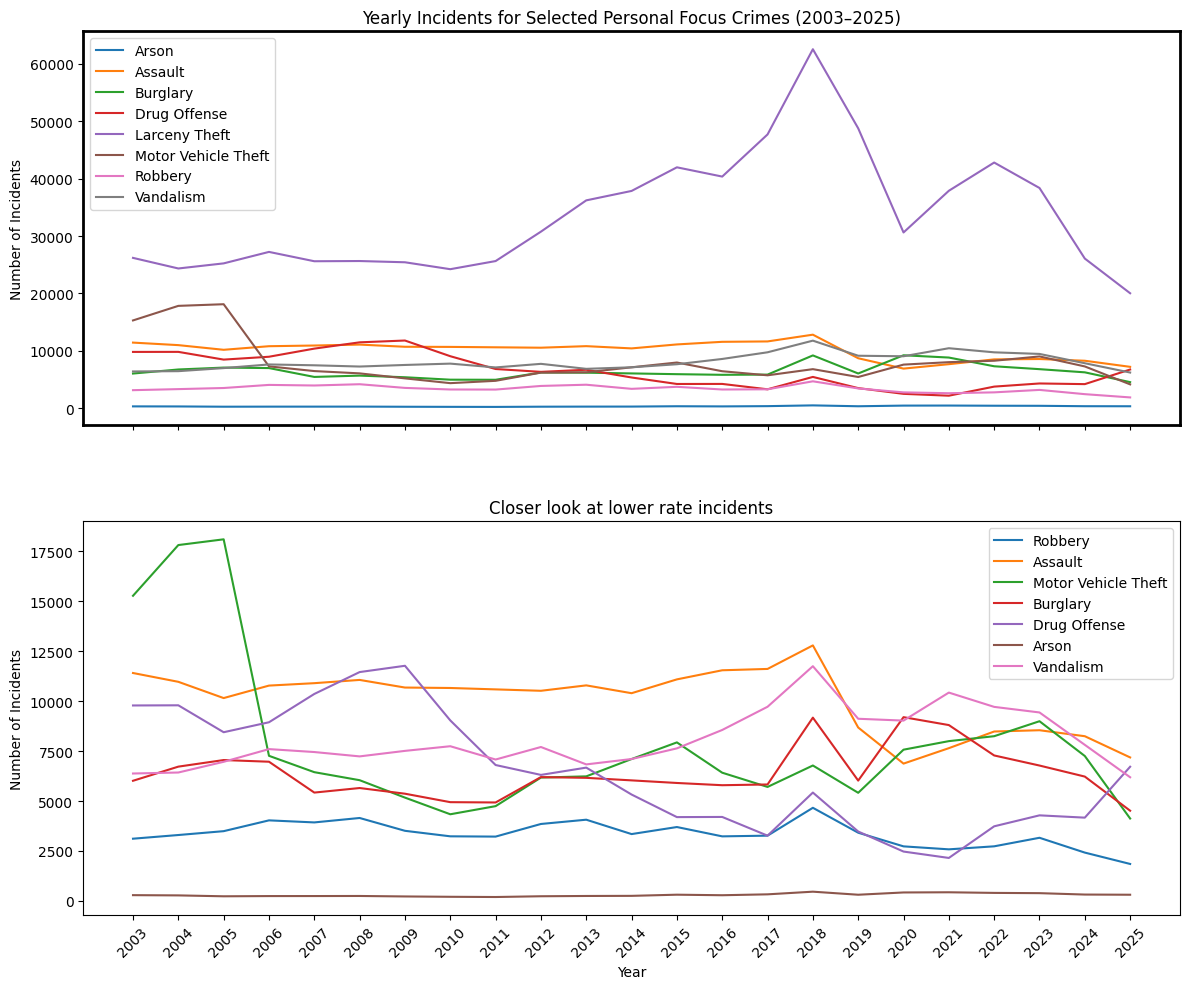

In [43]:
# Create figure with 2 vertical subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# -----------------------
# Plot 1: All crimes
# -----------------------
for crime in pivot_table.columns:
    axes[0].plot(pivot_table.index, pivot_table[crime], label=crime)

axes[0].set_ylabel("Number of Incidents")
axes[0].set_title(
    "Yearly Incidents for Selected Personal Focus Crimes (2003–2025)"
)
axes[0].legend()

# Thicker outline (double thickness)
for spine in axes[0].spines.values():
    spine.set_linewidth(2)

# -----------------------
# Plot 2: Excluding Larceny Theft
# -----------------------
crimes_excl_larceny = [crime for crime in focus_crimes if crime != "Larceny Theft"]

for crime in crimes_excl_larceny:
    axes[1].plot(pivot_table.index, pivot_table[crime], label=crime)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Incidents")
axes[1].set_title("Closer look at lower rate incidents")
axes[1].legend()

for ax in axes:
    ax.set_xticks(pivot_table.index)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(h_pad=5.0)
plt.show()


## Interpretation of Temporal Patterns

### Notable Feature 1: Sharp increase and subsequent decline in Larceny crime (2013–2020)

The data shows a marked increase in Larceny crime beginning around 2011, peaking at approximately 62,000 incidents in 2018, followed by a sharp decline in 2020 to roughly half that level. This is one of the most pronounced proportional fluctuation together with Motor Vehicle Theft among the selected crime types.

The increase likely reflects the broader rise in urban property crime during the mid-to-late 2010s, particularly crime from vehicles. The abrupt drop in 2020 coincides with the COVID-19 pandemic. Reduced tourism, mobility, and commuting likely reduced opportunities for crime. The scale of the decline suggests that routine activity patterns strongly influence property crime levels.

---

### Notable Feature 2: Gradual long-term decline in Drug Offenses

Drug Offenses exhibit a sustained downward trend from the mid-2000s to the early 2020s, declining from roughly 10,000–12,000 annual incidents to substantially lower levels after 2018. Unlike property crimes, this pattern appears gradual and structural.

This trend likely reflects changes in policing priorities, legal reforms, or enforcement intensity rather than shifts in underlying drug use. Because drug offenses are enforcement-driven, recorded incidents depend heavily on police activity. Reduced proactive enforcement or policy shifts toward decriminalization can therefore lower recorded incidents without necessarily reducing drug prevalence.


# Assignment 1.2 - Crime Profiles by Police District

## Objective

We quantify how crime types are distributed across police districts using conditional probabilities.

For each district and crime type, we compute:

$$
r(\text{crime}, \text{district}) 
= \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}
$$

Values:

- \> 1 → Over-represented
- < 1 → Under-represented
- = 1 → Matches city-wide distribution

In [44]:
# Total number of focus crime incidents
total_incidents = len(focus_data)

# City-wide probability of each crime
city_crime_counts = focus_data["Incident Category"].value_counts()

P_crime = city_crime_counts / total_incidents

P_crime

Incident Category
Larceny Theft          0.441080
Assault                0.132409
Vandalism              0.105999
Motor Vehicle Theft    0.103556
Drug Offense           0.085050
Burglary               0.084020
Robbery                0.043996
Arson                  0.003890
Name: count, dtype: float64

In [45]:
# Counting crimes per district and category
district_crime_counts = (
    focus_data
    .groupby(["Police District", "Incident Category"])
    .size()
    .reset_index(name="Count")
)

# Total incidents per district
district_totals = (
    focus_data
    .groupby("Police District")
    .size()
    .reset_index(name="District Total")
)

# Merging totals back
district_crime_counts = district_crime_counts.merge(
    district_totals,
    on="Police District"
)

# Computing conditional probability P(crime | district)
district_crime_counts["P_crime_given_district"] = (
    district_crime_counts["Count"] /
    district_crime_counts["District Total"]
)


In [46]:
# Mapping city-wide P(crime) into dataframe
district_crime_counts["P_crime_city"] = district_crime_counts["Incident Category"].map(P_crime)

# Computing ratio
district_crime_counts["r_value"] = (
    district_crime_counts["P_crime_given_district"] /
    district_crime_counts["P_crime_city"]
)


In [47]:
# Pivot table: districts x crimes
r_pivot = district_crime_counts.pivot(
    index="Police District",
    columns="Incident Category",
    values="r_value"
)

# REMOVE "Out of SF"
r_pivot = r_pivot.drop(index="Out of SF")

r_pivot

Incident Category,Arson,Assault,Burglary,Drug Offense,Larceny Theft,Motor Vehicle Theft,Robbery,Vandalism
Police District,,,,,,,,
Bayview,2.430966,1.336792,1.082653,0.811585,0.662739,1.637848,1.268471,1.281266
Central,0.749259,0.768225,0.981268,0.290224,1.327818,0.604585,0.831342,0.975272
Ingleside,1.222981,1.176739,1.120046,0.475703,0.698390,1.943553,1.366128,1.277847
Mission,1.039418,1.252278,0.912079,1.272322,0.835345,1.093335,1.303763,1.002502
Northern,0.800687,0.782470,1.118331,0.593450,1.206631,0.800004,0.812314,0.924911
Park,0.712382,0.770078,1.396795,0.803398,0.993471,1.291527,0.650445,1.028435
Richmond,0.859648,0.637257,1.209896,0.274660,1.185747,1.186902,0.582284,1.091745
Southern,0.770865,0.985349,0.827321,1.053432,1.160890,0.577880,0.949263,0.884671
Taraval,0.975913,0.850867,1.278862,0.334952,0.964243,1.481098,0.790243,1.265587


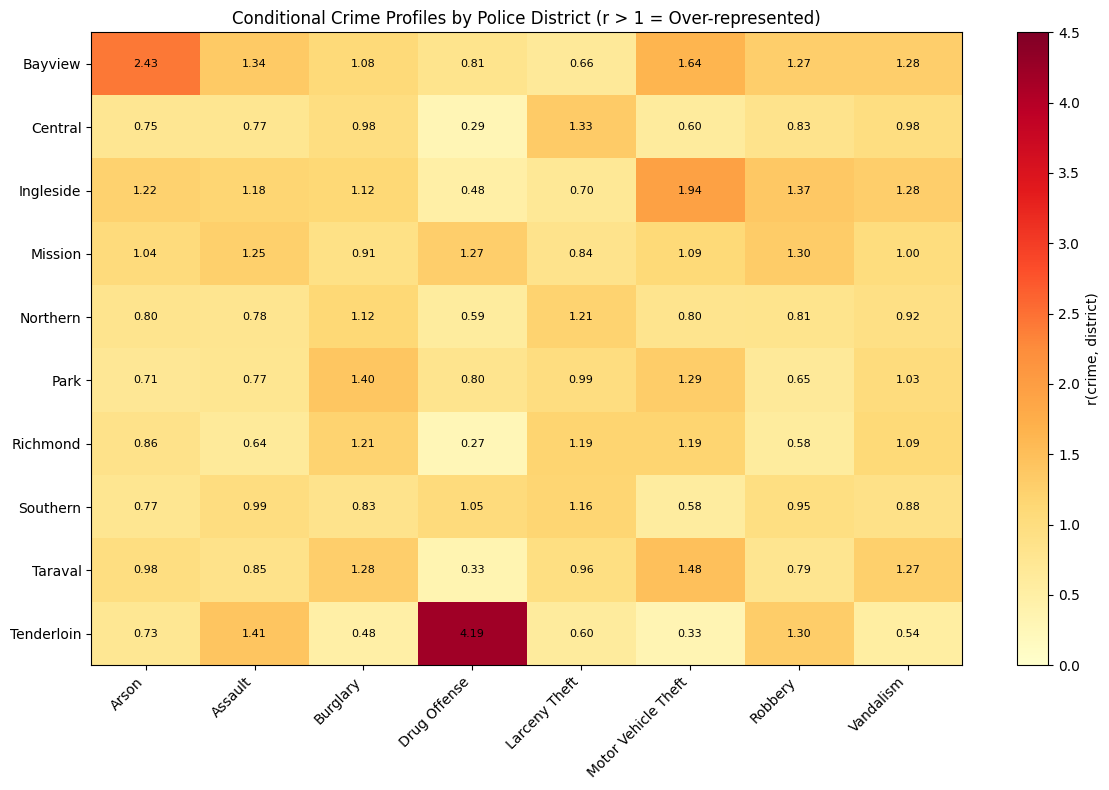

In [48]:
plt.figure(figsize=(12, 8))

# Plot heatmap
im = plt.imshow(
    r_pivot,
    aspect='auto',
    cmap="YlOrRd",
    vmin=0,
    vmax=4.5
)

# Add colorbar
plt.colorbar(im, label="r(crime, district)")

# Axis ticks
plt.xticks(
    ticks=np.arange(len(r_pivot.columns)),
    labels=r_pivot.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    ticks=np.arange(len(r_pivot.index)),
    labels=r_pivot.index
)

# Add numeric values inside cells
for i in range(r_pivot.shape[0]):
    for j in range(r_pivot.shape[1]):
        value = r_pivot.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title("Conditional Crime Profiles by Police District (r > 1 = Over-represented)")
plt.tight_layout()
plt.show()

## District Profile Interpretation  

### Selected District: Tenderloin  

Tenderloin stands out due to a highly asymmetric crime profile. Drug Offenses are extremely over-represented (r = 4.19), meaning the share of drug offenses in this district is more than four times the city-wide average. Assault (r = 1.41) and Robbery (r = 1.30) are also over-represented.

In contrast, several property crimes are under-represented relative to the city average, including Burglary (r = 0.48), Larceny Theft (r = 0.60), Motor Vehicle Theft (r = 0.33), and Vandalism (r = 0.54). Arson is also below the city average (r = 0.73).  

This pattern indicates a concentration of public-order and interpersonal offenses rather than property-based crimes.

### Possible Explanations  

Tenderloin is a dense, centrally located neighborhood characterized by high levels of street activity and visible drug markets. The extreme over-representation of drug offenses likely reflects both underlying drug activity and concentrated police enforcement. Because drug offenses are enforcement-driven, higher police presence can substantially increase recorded incidents.  

The under-representation of burglary and vehicle theft may reflect limited residential space, lower vehicle ownership, and fewer high-value private targets relative to other districts. The district’s land use patterns, concentration of social services, and demographic composition likely contribute to its distinctive crime profile.

# Assignment 1.3 - Visualizing Distributions

## Part A - Jitter Plot of Incident Times

### Objective

We examine the recording precision of incident times by creating a jitter plot for one crime type during a single hour interval.

Horizontal axis: time within the hour  
Vertical axis: artificial jitter for visualization

In [49]:
# Date interval (3 months)
start_date = pd.to_datetime('2018-03-01').date()
end_date   = pd.to_datetime('2018-09-01').date()

# Hour interval (23:00–23:59)
start_time = datetime.strptime('23:00', '%H:%M').time()
end_time   = datetime.strptime('23:59:59', '%H:%M:%S').time()

In [50]:
# Filter to burglary
data_burglary = data[data["Incident Category"] == "Burglary"]

# Filter date range
data_burglary = data_burglary[
    (data_burglary["Incident Datetime"].dt.date >= start_date) &
    (data_burglary["Incident Datetime"].dt.date <= end_date)
]

# Filter hour window
data_burglary = data_burglary[
    (data_burglary["Incident Datetime"].dt.time >= start_time) &
    (data_burglary["Incident Datetime"].dt.time <= end_time)
]

In [51]:
np.random.seed(42)

data_burglary["Jitter"] = np.random.uniform(
    low=-0.1,
    high=0.1,
    size=len(data_burglary)
)

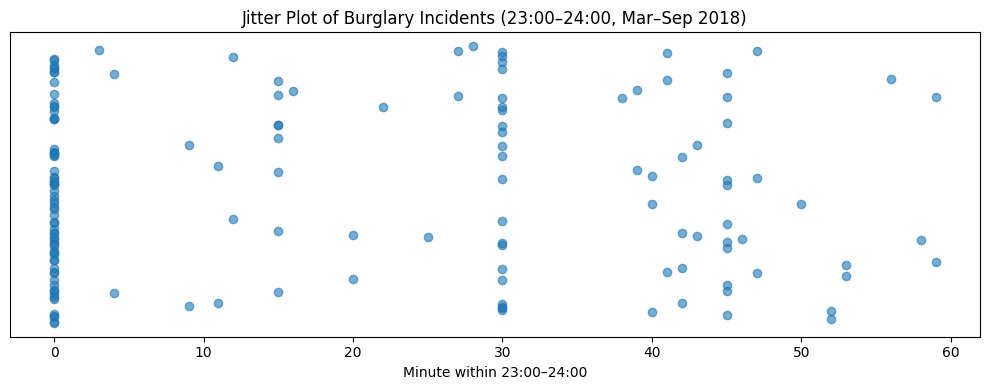

In [52]:
plt.figure(figsize=(10, 4))

plt.scatter(
    data_burglary["Incident Datetime"].dt.minute,
    data_burglary["Jitter"],
    alpha=0.6
)

plt.xlabel("Minute within 23:00–24:00")
plt.yticks([])
plt.title("Jitter Plot of Burglary Incidents (23:00–24:00, Mar–Sep 2018)")
plt.tight_layout()
plt.show()

## Interpretation

The jitter plot shows clear clustering at specific minutes, most notably at 00 minutes (23:00) and around 30 minutes (23:30). Additional smaller clusters appear at regular intervals (e.g., 15 and 45 minutes), while relatively fewer incidents are recorded at arbitrary minute values.

This pattern indicates that incident times are not recorded with fully continuous minute-level precision. Instead, many reports appear to be rounded to salient reference points such as the top or half of the hour.

The clustering at 23:00 is particularly pronounced, suggesting that when the exact time of occurrence is uncertain, incidents may default to the start of the hour. This implies limited temporal precision in the dataset and reflects reporting practices rather than true underlying crime timing patterns.

Overall, the plot suggests that recorded incident times are influenced by administrative rounding or estimation, meaning the dataset does not always represent exact occurrence times.


## Part B - Probability Plot of Latitude Distribution

### Objective

We compare the latitude distribution of two crime types to a normal reference distribution using QQ plots.

In [53]:
# We select two crime types with contrasting profiles
crime1 = "Drug Offense"
crime2 = "Larceny Theft"

# Filter and clean latitude data - remove sentinel values (e.g., lat = 90.0)
lat1 = focus_data[
    (focus_data["Incident Category"] == crime1) &
    (focus_data["Latitude"] < 90)
]["Latitude"].dropna()

lat2 = focus_data[
    (focus_data["Incident Category"] == crime2) &
    (focus_data["Latitude"] < 90)
]["Latitude"].dropna()

# Create side-by-side QQ plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, lat_data, crime in zip(axes, [lat1, lat2], [crime1, crime2]):
    (osm, osr), (slope, intercept, r) = stats.probplot(lat_data, dist="norm", plot=None)
    ax.plot(osm, osr, '.', alpha=0.15, markersize=2, color="steelblue", label="Observed")
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5, label=f"Normal reference (R={r:.3f})")
    ax.set_title(f"QQ Plot - {crime}", fontsize=13)
    ax.set_xlabel("Theoretical Quantiles (Normal)")
    ax.set_ylabel("Sample Quantiles (Latitude)")
    ax.legend(fontsize=9)

plt.suptitle("QQ Plots of Latitude Distribution by Crime Type", fontsize=14)
plt.tight_layout()
plt.show()

print(f"{crime1}: n = {len(lat1):,}   latitude range [{lat1.min():.4f}, {lat1.max():.4f}]")
print(f"{crime2}: n = {len(lat2):,}   latitude range [{lat2.min():.4f}, {lat2.max():.4f}]")


TypeError: '<' not supported between instances of 'str' and 'int'


## Interpretation

**Reference distribution:** Normal distribution. If points lie exactly on the red line, the latitude distribution is perfectly normal.

### Drug Offense

Drug Offense incidents are strongly concentrated in the Tenderloin district (r = 4.19 from Assignment 1.2), a small area in central SF. The QQ plot shows a pronounced **S-shaped deviation**, reflecting that a large fraction of incidents cluster around one latitude band (~37.78°N). The tails deviate from the normal reference line, indicating a heavy-concentration, non-normal distribution with a prominent central spike rather than a smooth bell curve.

### Larceny Theft

Larceny Theft is distributed more evenly across the city (over-represented in Central, Northern, and Southern districts). Its QQ plot tracks the reference line more closely in the central quantiles, but there is some deviation in the extreme tails - reflecting geographic constraints (SF is bounded by the Bay to the north and east, and by hills to the west and south).

### Key Takeaway

Neither crime type is expected to follow a normal latitude distribution. Drug Offense departs more strongly due to extreme spatial concentration in a single district, while Larceny Theft departs more subtly, reflecting the city's geographic shape. These deviations from normality confirm that latitude alone is insufficient to describe crime geography - spatial clustering and physical boundaries drive the non-normality observed.


## Part C - Time-of-Day Distributions

### Objective

We compare the time-of-day distribution across all Personal Focus Crimes.

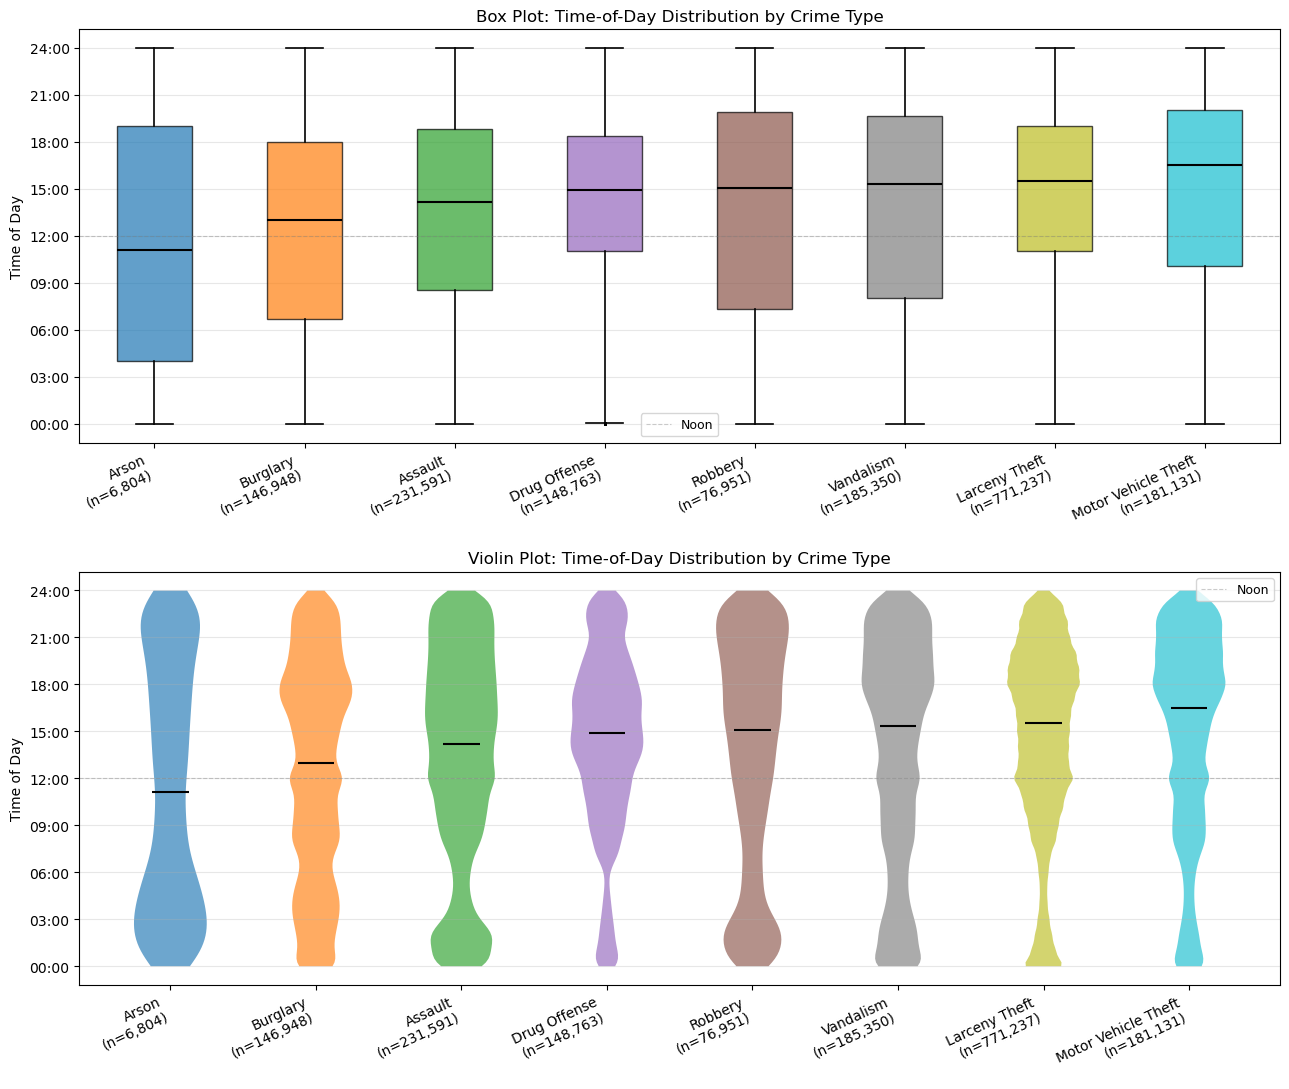

In [ ]:

# Extract time of day as decimal hours (0.0 = midnight, 23.99 = just before midnight)
time_data = focus_data.copy()
time_data["TimeOfDay"] = (
    time_data["Incident Datetime"].dt.hour +
    time_data["Incident Datetime"].dt.minute / 60
)

# Order crimes by median time of day (earliest to latest)
crime_order = (
    time_data.groupby("Incident Category")["TimeOfDay"]
    .median()
    .sort_values()
    .index.tolist()
)

# Build per-crime data lists
data_lists = [
    time_data[time_data["Incident Category"] == c]["TimeOfDay"].dropna().values
    for c in crime_order
]

colors = plt.cm.tab10(np.linspace(0, 1, len(crime_order)))
yticks      = range(0, 25, 3)
yticklabels = [f"{h:02d}:00" for h in yticks]

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

# ── Box plot ──────────────────────────────────────────────────────────────────
ax = axes[0]
bp = ax.boxplot(
    data_lists, labels=crime_order, vert=True, patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='.', markersize=1, alpha=0.2)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(crime_order) + 1))
ax.set_xticklabels(
    [f"{c}\n(n={len(d):,})" for c, d in zip(crime_order, data_lists)],
    rotation=25, ha='right'
)
ax.set_ylabel("Time of Day")
ax.set_title("Box Plot: Time-of-Day Distribution by Crime Type")
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.axhline(y=12, color='gray', linestyle='--', alpha=0.4, linewidth=0.8, label="Noon")
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

# ── Violin plot ───────────────────────────────────────────────────────────────
ax = axes[1]
vp = ax.violinplot(
    data_lists,
    positions=range(1, len(crime_order) + 1),
    showmedians=True,
    showextrema=False
)
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color)
    body.set_alpha(0.65)
vp['cmedians'].set_color('black')
vp['cmedians'].set_linewidth(1.5)

ax.set_xticks(range(1, len(crime_order) + 1))
ax.set_xticks(range(1, len(crime_order) + 1))
ax.set_xticklabels(
    [f"{c}\n(n={len(d):,})" for c, d in zip(crime_order, data_lists)],
    rotation=25, ha='right'
)
ax.set_ylabel("Time of Day")
ax.set_title("Violin Plot: Time-of-Day Distribution by Crime Type")
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.axhline(y=12, color='gray', linestyle='--', alpha=0.4, linewidth=0.8, label="Noon")
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()



## Interpretation 

### Interpreting the plots
From the boxplot, we observe that several crime types have medians in the late evening. However, none of them appear to occur very frequently extremely late at night. This may be partly due to the data being cut off at midnight. Incidents that occur shortly after midnight (very early morning) are recorded as low values, which pulls the lower quartile downward and can influence how we interpret the median.

The violin plots provide a more detailed view of the distribution and help explain this pattern. In particular, crime types such as Arson, Assault, and Robbery show noticeable peaks in the very early morning and late-night hours. However, as seen in Exercise 1.3 with the jitter plots, some crime types tend to be reported at exact hours or half-hours. This reporting pattern can create artificial peaks in the violin plots, which display the data with high precision. Therefore, some of the sharp features in the violins may reflect reporting practices rather than true incident patterns.

That said, the overall tendency of increasing crime frequency toward the evening and early morning is still visible. The sharp drop in frequencies around midnight is likely due to how the data are recorded, rather than a sudden real-world decrease in incidents.

For Arson, Vandalism, and Robbery, the IQRs (Interquartile Ranges) are relatively large, indicating high variability in incident times. This makes it more difficult to identify clear time-of-day patterns for these crimes. The violin plots suggest that this wide spread is partly driven by a high number of early-morning incidents.

Burglary appears to have the most evenly distributed frequency throughout the day, with a median close to noon. Since there are no strong artificial peaks at exact hour or half-hour intervals and no extremely narrow “waists” in the violin plot, this distribution seems more reliable. Howver the even distribution can be due to the time reccorded beeing time of discovery and not time of the incident as this can be hard to identify. Drug Offense and Assault are the two crime types that occur relatively frequently earlier in the day. Drug Offense is particularly interesting, as it peaks around 3 PM and then gradually decreases toward the late evening.

### Interpreting the plots

Crimes such as Assault and Robbery peaking in the late evening and early morning may be linked to nightlife activity, alcohol consumption, reduced guardianship, and increased social interaction during those hours. Arson and Vandalism showing substantial later night and early-morning activity could reflect lower visibility and fewer witnesses at night, creating more opportunities for such offenses. In contrast, burglary’s relatively even distribution throughout the day may be influenced by the fact that these incidents are often discovered and reported after they occur, meaning the recorded time may reflect discovery rather than the actual event. Drug offenses peaking in the afternoon may be shaped less by actual usage patterns and more by policing strategies, such as daytime patrol and enforcement intensity. 


# Assignment 1.4 - Spatial Power Law

## Objective

We test whether crime incidents follow a spatial power-law distribution.

We divide San Francisco into ~100m × 100m grid cells and analyze incident concentration.

In [ ]:
# ── Steps 1-3: grid SF, count crimes per cell, tally N(k) ──────────────────

# Step 1: Filter for Larceny crime and clip to SF peninsula
#   • 1° latitude  ≈ 111 km  →  100 m ≈ 0.0009°
#   • 1° longitude at 37.75°N ≈ 88 km  →  100 m ≈ 0.00114°
most_common = focus_data['Incident Category'].value_counts().idxmax()

crime = focus_data[focus_data['Incident Category'].str.contains(most_common, case=False, na=False)].copy()

# Remove outliers: keep only the SF peninsula bounding box
crime = crime[
    crime['Latitude'].between(37.70, 37.83) &
    crime['Longitude'].between(-122.53, -122.35)
].copy()

print(f"{most_common} incidents on SF peninsula: {len(crime):,}")

# Step 1 (cont.): build ~100 m grid bins
lat_bin_size = 0.0009    # ≈ 100 m N-S
lon_bin_size = 0.00114   # ≈ 100 m E-W at SF latitude

lat_bins = np.arange(37.70,  37.83  + lat_bin_size, lat_bin_size)
lon_bins = np.arange(-122.53, -122.35 + lon_bin_size, lon_bin_size)

# Step 2: count crimes in every cell (np.histogram2d returns a 2-D array)
H, _, _ = np.histogram2d(
    crime['Latitude'].values,
    crime['Longitude'].values,
    bins=[lat_bins, lon_bins]
)
counts = H.flatten().astype(int)   # one entry per grid cell

n_cells = len(counts)
k_max   = int(counts.max())
print(f"Grid: {len(lat_bins)-1} rows × {len(lon_bins)-1} cols = {n_cells:,} cells")
print(f"Max {most_common}s in one cell: {k_max}")
print(f"Cells with 0 {most_common}s:    {(counts == 0).sum():,}  ({100*(counts==0).mean():.1f}%)")

# Step 3: tally N(k) - how many cells have exactly k crimes
k_values = np.arange(0, k_max + 1)
N_k      = np.array([(counts == k).sum() for k in k_values])

print(f"\nN(k=0)={N_k[0]:,},  N(k=1)={N_k[1]:,},  N(k=10)={N_k[10]:,},  N(k={k_max})={N_k[-1]:,}")

Larceny Theft incidents on SF peninsula: 744,095
Grid: 145 rows × 158 cols = 22,910 cells
Max Larceny Thefts in one cell: 17151
Cells with 0 Larceny Thefts:    14,158  (61.8%)

N(k=0)=14,158,  N(k=1)=159,  N(k=10)=201,  N(k=17151)=1


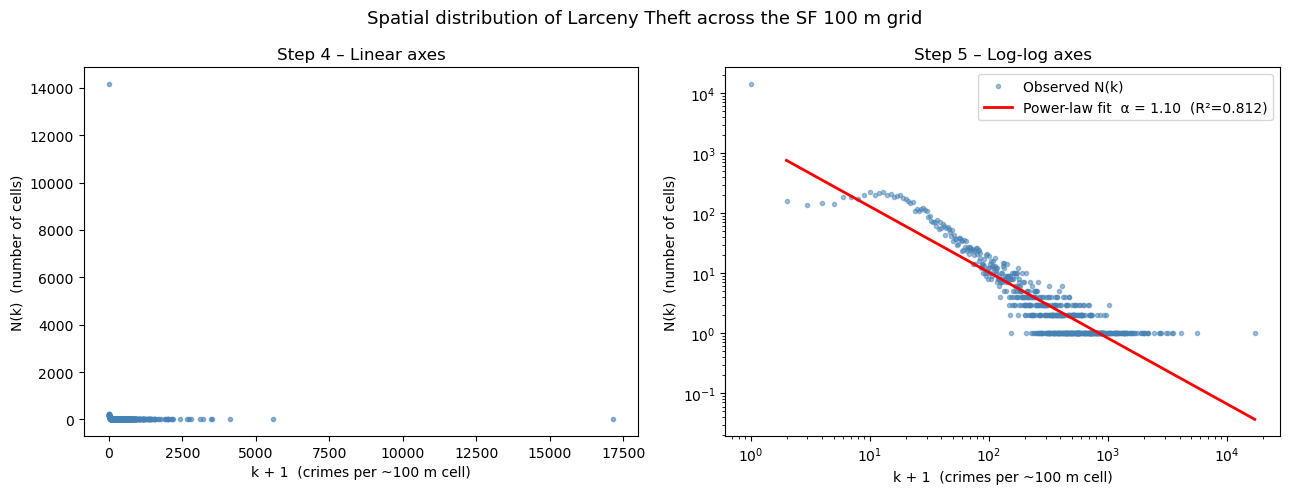


Power-law exponent  α ≈ 1.10
R² of log-log fit   = 0.812


In [ ]:
# ── Steps 4-5: plot the distribution on linear and log-log axes ─────────────

# Only use k-values where at least one cell exists (N_k > 0)
mask   = N_k > 0
k_plot = k_values[mask]        # k
N_plot = N_k[mask]             # N(k)
x_plot = k_plot + 1            # x-axis = k+1  (avoids log(0) when k=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Step 4: linear axes ──────────────────────────────────────────────────────
axes[0].plot(x_plot, N_plot, 'o', markersize=3, alpha=0.6, color='steelblue')
axes[0].set_xlabel('k + 1  (crimes per ~100 m cell)')
axes[0].set_ylabel('N(k)  (number of cells)')
axes[0].set_title('Step 4 – Linear axes')

# ── Step 5: log-log axes + power-law fit ────────────────────────────────────
axes[1].loglog(x_plot, N_plot, 'o', markersize=3, alpha=0.5, color='steelblue',
               label='Observed N(k)')

# Fit a power law in log-log space: log N = -α log(k+1) + c
# Use only cells with k >= 1 to avoid the large N(0) spike distorting the tail
fit_mask = k_plot >= 1
log_x = np.log10(x_plot[fit_mask])
log_y = np.log10(N_plot[fit_mask])

slope, intercept, r, p, _ = stats.linregress(log_x, log_y)
x_fit = np.linspace(x_plot[fit_mask][0], x_plot[fit_mask][-1], 200)
y_fit = 10**(intercept + slope * np.log10(x_fit))

axes[1].loglog(x_fit, y_fit, 'r-', linewidth=2,
               label=f'Power-law fit  α = {-slope:.2f}  (R²={r**2:.3f})')
axes[1].set_xlabel('k + 1  (crimes per ~100 m cell)')
axes[1].set_ylabel('N(k)  (number of cells)')
axes[1].set_title('Step 5 – Log-log axes')
axes[1].legend()

plt.suptitle(f'Spatial distribution of {most_common} across the SF 100 m grid', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nPower-law exponent  α ≈ {-slope:.2f}")
print(f"R² of log-log fit   = {r**2:.3f}")

## Interpretation

### Does the distribution follow a power law?

Yes, the crime data appears to follow a power-law spatial distribution. You can tell from the log-log plot because:
- **Linearity**: On the log-log axes (Step 5), the data points (blue dots) roughly align along a straight downward-sloping path. In a log-log environment, a straight line is the signature of a power law.
- **The Fit Line**: The red line represents the power-law fit with an exponent $\alpha = 1.10$. The $R^2$ value of 0.812 indicates a strong correlation, meaning the power-law model explains a high percentage of the variance in the spatial distribution.
- **Extreme Variance**: In the linear plot (Step 4), you see a "Long Tail." A vast majority of 100 m cells have near-zero crimes, while a tiny handful of "hotspot" cells have a massive number (up to 17,500+).
---

### What the exponent α ≈ 1.10 tells us

A power-law exponent near 1 indicates an **extremely heavy tail**. The distribution decays very slowly: there are far more high-count cells than would be expected under a normal or exponential distribution. Crime is not merely "somewhat concentrated" - it is dominated by a small number of extreme hotspots. The single cell with ~17,500 incidents (likely a dense commercial corridor such as Union Square) represents a concentration roughly **200 times** the mean of non-zero cells (~85 incidents/cell).

---

### Spatial concentration and the "average block"

With 61.8% of cells recording zero incidents and a handful of cells accumulating tens of thousands of incidents, the spatial distribution is highly unequal. The city-wide mean of ~32 incidents per cell (744,095 / 22,910) is a misleading summary statistic - it is pulled upward by extreme hotspots while the majority of the grid has no activity at all. This is a classic property of heavy-tailed distributions: the mean is not representative of the typical location.

For policing and urban planning, this implies that **targeted hotspot interventions** affecting a small fraction of grid cells could account for a disproportionately large share of total incidents - a substantially more efficient strategy than uniform city-wide enforcement.

# Assignment 1.5 - Regression and Correlation

## Objective

We analyze weekly rhythms across crime types by:

1. Computing 168-hour weekly incident vectors
2. Creating pairwise scatterplot matrix
3. Fitting regression lines using closed-form equations
4. Computing and displaying R² values

In [ ]:
focus_crimes

['Robbery',
 'Assault',
 'Motor Vehicle Theft',
 'Burglary',
 'Larceny Theft',
 'Drug Offense',
 'Arson',
 'Vandalism']

In [ ]:

# ── Weekly aggregation (168-hour vectors) ─────────────────────────────────────
selected_crimes = ['Robbery',
 'Larceny Theft',
 'Drug Offense',
 'Vandalism']   

wh_data = focus_data.copy()
wh_data["DayOfWeek"] = wh_data["Incident Datetime"].dt.dayofweek  # Mon=0, Sun=6
wh_data["Hour"]      = wh_data["Incident Datetime"].dt.hour
wh_data["WeekHour"]  = wh_data["DayOfWeek"] * 24 + wh_data["Hour"]

weekly = {}
for crime in selected_crimes:
    counts = (
        wh_data[wh_data["Incident Category"] == crime]
        .groupby("WeekHour").size()
        .reindex(range(168), fill_value=0)
    )
    weekly[crime] = counts.values.astype(float)

print("168-hour weekly vectors built for:")
for crime, vec in weekly.items():
    print(f"  {crime:<22}  total={int(vec.sum()):>7,}  "
          f"mean={vec.mean():.1f}  max={int(vec.max()):>5}")

# ── Closed-form regression (per assignment formulas) ──────────────────────────
def regress(x, y):
    """y = ax + b  via closed-form normal equations."""
    N  = len(x)
    xm = x.mean()
    ym = y.mean()
    a  = (x @ y - N * xm * ym) / (x @ x - N * xm**2)
    b  = ym - a * xm
    return a, b

def r_squared(x, y, a, b):
    """Coefficient of determination R²."""
    ss_res = ((y - (a * x + b)) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    return 1.0 if ss_tot == 0 else 1.0 - ss_res / ss_tot


168-hour weekly vectors built for:
  Robbery                 total= 76,951  mean=458.0  max=  912
  Larceny Theft           total=771,237  mean=4590.7  max= 9274
  Drug Offense            total=148,763  mean=885.5  max= 2315
  Vandalism               total=185,350  mean=1103.3  max= 2227


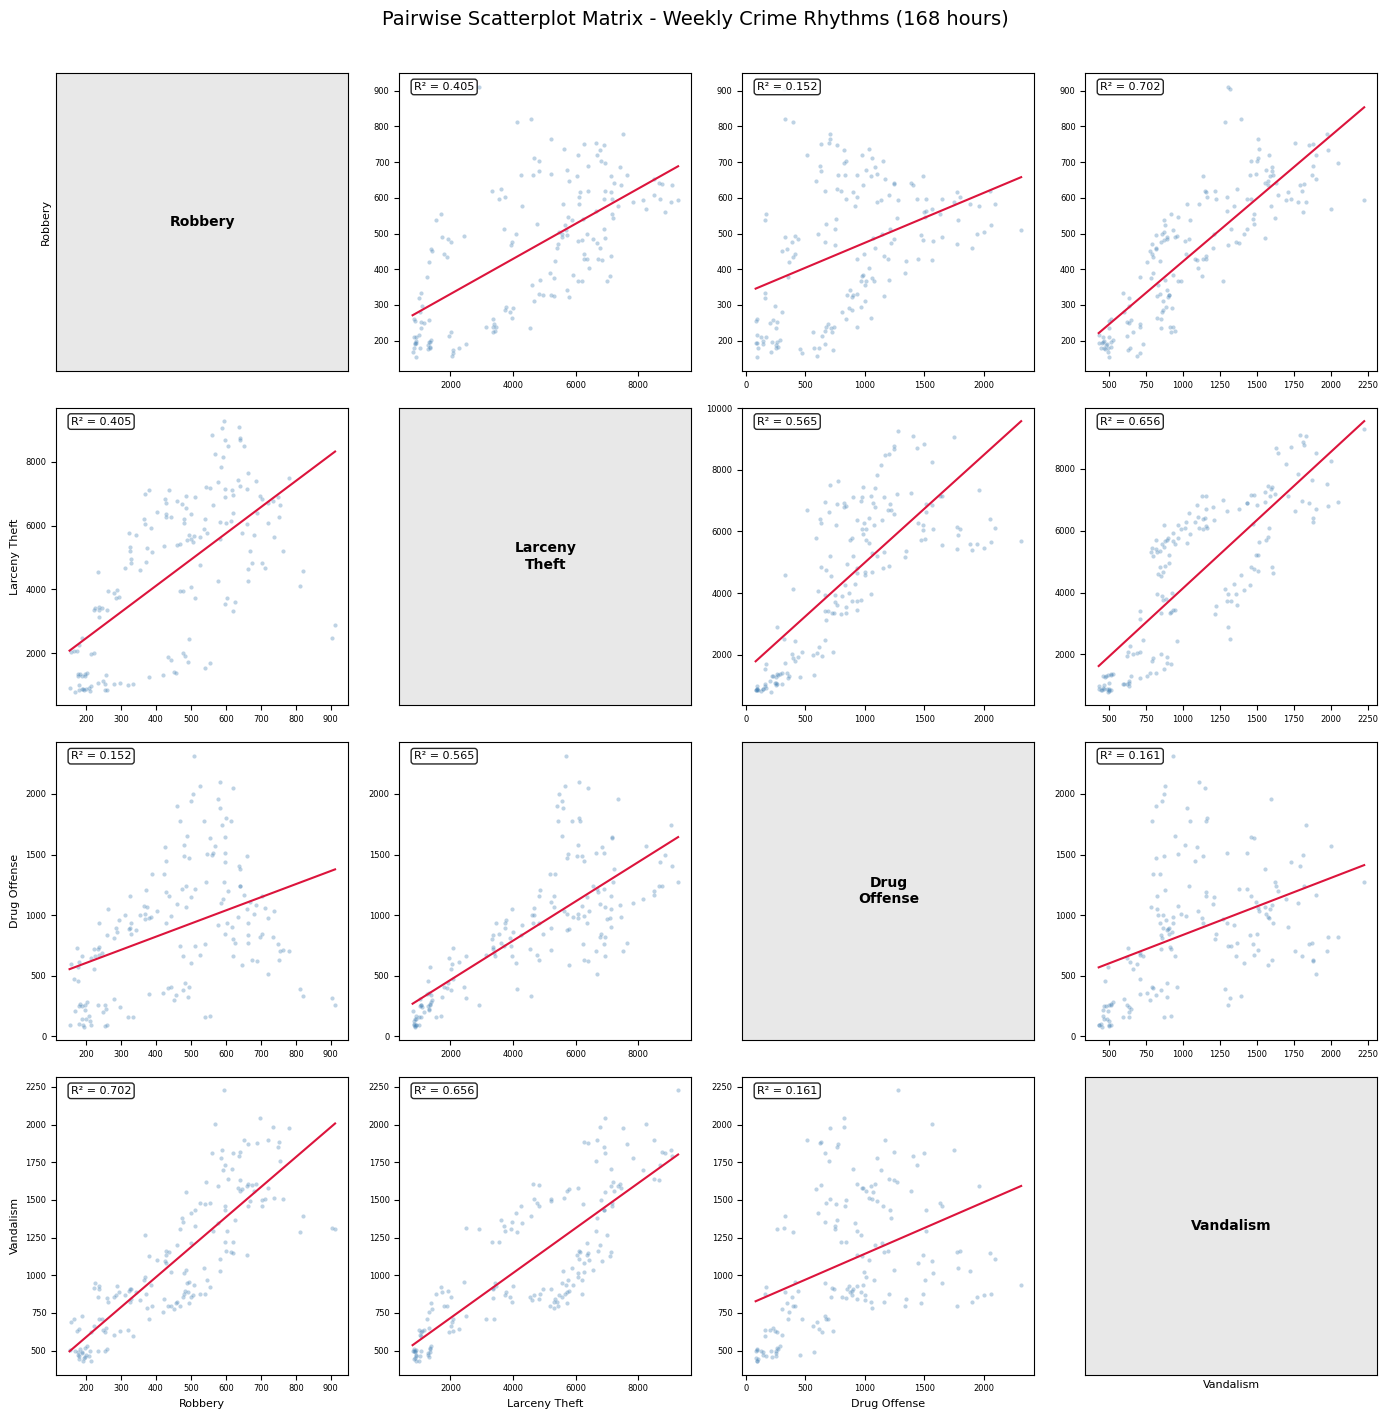

Pairwise R² values (ranked):

  Robbery                 vs  Vandalism               R² = 0.7016
  Larceny Theft           vs  Vandalism               R² = 0.6564
  Larceny Theft           vs  Drug Offense            R² = 0.5654
  Robbery                 vs  Larceny Theft           R² = 0.4046
  Drug Offense            vs  Vandalism               R² = 0.1608
  Robbery                 vs  Drug Offense            R² = 0.1517


In [ ]:

# ── Scatterplot matrix ─────────────────────────────────────────────────────────
n = len(selected_crimes)

fig, axes = plt.subplots(n, n, figsize=(14, 14))
fig.suptitle(
    "Pairwise Scatterplot Matrix - Weekly Crime Rhythms (168 hours)",
    fontsize=14, y=1.01
)

# Collect R² values for summary
r2_results = []

for i, crime_y in enumerate(selected_crimes):
    for j, crime_x in enumerate(selected_crimes):
        ax = axes[i, j]

        if i == j:
            # Diagonal: show crime name
            ax.set_facecolor("#e8e8e8")
            ax.text(
                0.5, 0.5,
                crime_y.replace(" ", "\n"),
                ha="center", va="center",
                fontsize=10, fontweight="bold",
                transform=ax.transAxes
            )
            ax.set_xticks([])
            ax.set_yticks([])

        else:
            x = weekly[crime_x]
            y = weekly[crime_y]

            # Closed-form regression
            a, b = regress(x, y)
            r2   = r_squared(x, y, a, b)

            if j < i:
                r2_results.append((r2, crime_x, crime_y))

            # Scatter points (one per hour-of-week)
            ax.scatter(x, y, alpha=0.35, s=9, color="steelblue", linewidths=0)

            # Regression line
            x_fit = np.array([x.min(), x.max()])
            ax.plot(x_fit, a * x_fit + b, color="crimson", linewidth=1.5)

            # R² annotation
            ax.text(
                0.05, 0.97, f"R² = {r2:.3f}",
                transform=ax.transAxes, fontsize=8,
                va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.85)
            )
            ax.tick_params(labelsize=6)

        # Outer-edge axis labels
        if j == 0:
            ax.set_ylabel(crime_y, fontsize=8, labelpad=4)
        if i == n - 1:
            ax.set_xlabel(crime_x, fontsize=8, labelpad=4)

plt.tight_layout()
plt.show()

# ── Correlation ranking ────────────────────────────────────────────────────────
r2_results.sort(reverse=True)
print("Pairwise R² values (ranked):\n")
for r2, cx, cy in r2_results:
    print(f"  {cx:<22}  vs  {cy:<22}  R² = {r2:.4f}")



## Interpretation

### Most correlated pair: Robbery and Vandalism

Both crimes peak strongly during late-night weekend hours - the same concentrated Friday and Saturday night windows when social activity, alcohol consumption, and reduced surveillance overlap. Their shared weekly rhythm means the 168-hour vectors closely track each other, yielding the highest R² among the four pairs. This is somewhat intuitive: both crimes thrive under similar environmental conditions (darkness, crowds, impaired bystanders), even though their underlying motivations differ.

### Least correlated pair: Drug Offense and Larceny Theft

These two have almost opposite temporal rhythms. Larceny Theft concentrates heavily during daytime business hours - Monday to Friday, roughly 10:00–18:00 - driven by shoplifting, vehicle break-ins, and street theft in busy commercial areas. Drug Offense, by contrast, peaks in the late evening and night, concentrated in the Tenderloin and driven by street-market activity after dark. Because their within-week patterns are near mirror images, the regression line fits poorly and R² is low. This mismatch is not surprising: one crime thrives on daytime foot traffic while the other thrives on nighttime concealment.

### Why two crime types can share a weekly rhythm

A high R² between two crime types does not mean one causes the other. Rather, it reflects a common environmental driver - the weekly social calendar. Crimes that both respond to nightlife (bar closing times, weekend gatherings, late-night transit) will naturally co-vary across the 168 hours. The shared weekly rhythm emerges from shared opportunity structure, not from any direct link between the crime types themselves.

Conversely, crimes whose opportunities are structured by different social logics (work schedules vs. night-time street markets) will show low correlation even though both are well-explained by their own weekly cycle.


# Contributions

All members contributed equally to coding, discussion, interpretation, and final review.